In [2]:
%cd /opt/tiger/samantha
!pip3 install ujson

/opt/tiger/samantha


/home/tiger/.local/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://bytedpypi.byted.org/simple/
DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [3]:
%load_ext autoreload
%autoreload 2

In [3]:
from samantha.dataio.data_bucket import data_bucket
from recipes.mi1.data_enriched.reader import IndexReader

2023-12-15 02:25:50,094 - numexpr.utils - INFO - Note: detected 128 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
2023-12-15 02:25:50,095 - numexpr.utils - INFO - Note: NumExpr detected 128 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.


In [7]:
url2index = data_bucket(
    "data/music/converted/CombinedTaggingDataModule_MI1_MusicTagging/test/url2index.txt"
)
print(url2index)
reader = IndexReader(url2index)

hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data/js/data/music/converted/CombinedTaggingDataModule_MI1_MusicTagging/test/url2index.txt
Loaded 5 index urls


100%|██████████| 5/5 [00:00<00:00,  7.77it/s]


In [8]:
reader.indexes

,shard,key,input_length,tag,tag_names,index_url
0,pipe: hdfs dfs -cat hdfs://harunava/home/byte_...,d376a987-2662-4a71-b686-c1c476e971ba,698976,"tensor([0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,...","[[classical, strings, violin, opera]]",hdfs://harunava/home/byte_data_seed_us/hdd_va/...
1,pipe: hdfs dfs -cat hdfs://harunava/home/byte_...,e6425762-0125-44a8-8c7c-46e44d9067a0,698976,"tensor([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,...","[[slow, ambient]]",hdfs://harunava/home/byte_data_seed_us/hdd_va/...
2,pipe: hdfs dfs -cat hdfs://harunava/home/byte_...,a7832b04-9360-43a3-ab4b-1fde91b90814,698976,"tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",[drums],hdfs://harunava/home/byte_data_seed_us/hdd_va/...
3,pipe: hdfs dfs -cat hdfs://harunava/home/byte_...,dbdba0ac-8700-43ec-9427-cb25e863d319,698976,"tensor([0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,...","[[techno, fast, vocals, male vocal, pop, beats]]",hdfs://harunava/home/byte_data_seed_us/hdd_va/...
4,pipe: hdfs dfs -cat hdfs://harunava/home/byte_...,bd2b6615-5fe9-47c5-8263-fbb3c2dbf146,698976,"tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[female, opera, singing, quiet, woman, soft]]",hdfs://harunava/home/byte_data_seed_us/hdd_va/...
...,...,...,...,...,...,...
4327,pipe: hdfs dfs -cat hdfs://harunava/home/byte_...,58bafbfd-74bb-41b7-9a4f-3b0436e7612b,698976,"tensor([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,...","[[classical, violin, opera, woman]]",hdfs://harunava/home/byte_data_seed_us/hdd_va/...
4328,pipe: hdfs dfs -cat hdfs://harunava/home/byte_...,20d4a4b3-c61c-4ab6-9a9b-63b52d2dcb98,698976,"tensor([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,...","[[strings, ambient]]",hdfs://harunava/home/byte_data_seed_us/hdd_va/...
4329,pipe: hdfs dfs -cat hdfs://harunava/home/byte_...,f608e6fa-a673-4240-a301-b5671fe6deae,698976,"tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,...","[[drums, ambient, beat]]",hdfs://harunava/home/byte_data_seed_us/hdd_va/...
4330,pipe: hdfs dfs -cat hdfs://harunava/home/byte_...,4ed0c4b5-f6f0-4beb-a5be-581480aa1165,698976,"tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,...","[[fast, male vocal, pop, beats]]",hdfs://harunava/home/byte_data_seed_us/hdd_va/...


<Axes: title={'center': 'Top-50 tags in MTAT (train)'}>

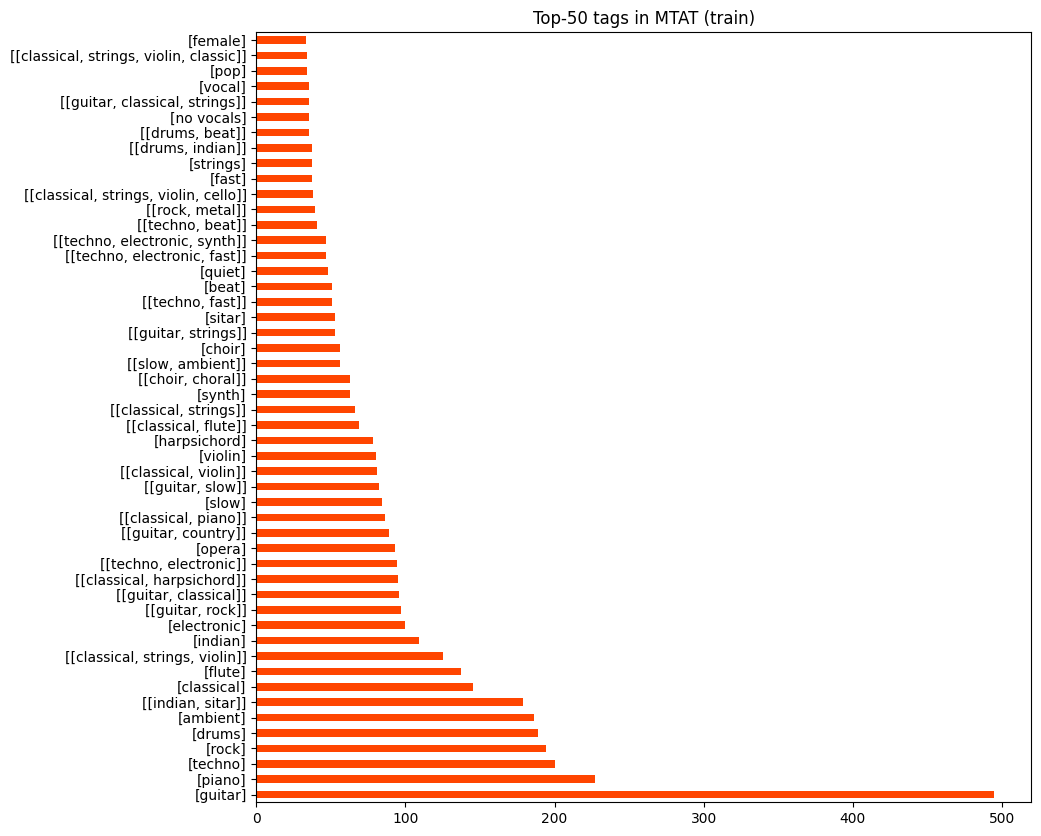

In [6]:
reader.indexes.tag_names.value_counts()[:50].plot.barh(figsize=(10,10), title="Top-50 tags in MTAT (train)", color="orangered")

In [36]:
from recipes.datasets.preprocessed.generic import GenericPreprocessedDataModule

batch_size = 128

datamodule = GenericPreprocessedDataModule(
    sample_rate=24000,
    train_url2index="data/music/converted/CombinedTaggingDataModule_MI1_MusicTagging/train/url2index.txt",
    validation_url2index="data/music/converted/CombinedTaggingDataModule_MI1_MusicTagging/validation/url2index.txt",
    test_url2index="data/music/converted/CombinedTaggingDataModule_MI1_MusicTagging/test/url2index.txt",
    batch_size=batch_size,
    shuffle_buffer_size=200,
    resampled=False,
    shardshuffle=False,
    num_workers=8,
)

In [37]:
data_loader = datamodule.test_dataloader()

In [38]:
from tqdm import tqdm

all_hidden_states = []
for batch in tqdm(data_loader):
    all_hidden_states.append(batch.hidden_states)
    

30it [00:18,  1.63it/s]


In [46]:
import torch
all_hidden_states = torch.stack(all_hidden_states, dim=0)

In [48]:
flat_hidden_states = all_hidden_states.reshape(-1, 728, 1024)

In [50]:
flat_hidden_states = flat_hidden_states.mean(dim=1)